### Predicción de rendimiento académico con MLP

# 🎯 Objetivo

Construir y evaluar un Perceptrón Multicapa (MLP) que clasifique el rendimiento académico de cada estudiante en Bajo / Medio / Alto a partir de variables observables (por ejemplo: estado_tareas, indice_asistencia, horas_sueno, tiempo_redes, etc.).
Uso principal: alertas tempranas, priorización de apoyo y monitoreo.

Target:
0 = Bajo, 1 = Medio, 2 = Alto

## 0) Configuración y dependencias

Importa librerías (TensorFlow, sklearn, matplotlib) y fija semillas para reproducibilidad.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print(tf.__version__)


2.19.0


## 1) Cargar datos

Lee el CSV, separa X (one-hot) y y (target 0/1/2).

In [ ]:
import os
path = "rendimiento_sintetico_nn_500.csv"
if not os.path.exists(path):
    try:
        from google.colab import files
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
    except Exception as e:
        print("Sube el archivo manualmente:", e)
df = pd.read_csv(path)
display(df.head())
print("Shape:", df.shape)
assert "target" in df.columns, "Se espera columna target"
X = df.drop(columns=["target"]).astype("float32")
y = df["target"].astype("int32")


,estado_tareas_Completo,estado_tareas_NoCompleto,estado_tareas_Parcial,indice_asistencia_Alta,indice_asistencia_Baja,indice_asistencia_Media,horas_sueno_Adecuado,horas_sueno_Corto,horas_sueno_Largo,tiempo_redes_Alto,...,dispositivo_propio_comparte,dispositivo_propio_noTiene,dispositivo_propio_si,tecnologia_educativa_Frecuente,tecnologia_educativa_NoUsa,tecnologia_educativa_Ocasional,acceso_internet_Aveces,acceso_internet_NoTiene,acceso_internet_Siempre,target
0,0,0,1,0,0,1,1,0,0,1,...,0,0,1,1,0,0,0,1,0,1
1,1,0,0,0,0,1,1,0,0,0,...,0,0,1,1,0,0,0,0,1,2
2,0,1,0,0,1,0,1,0,0,0,...,0,0,1,1,0,0,0,0,1,0
3,0,0,1,1,0,0,1,0,0,1,...,0,0,1,1,0,0,1,0,0,2
4,1,0,0,1,0,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,2


Shape: (500, 48)


## 2) Split estratificado: train/val/test

Divide en train/val/test y calcula class_weight para compensar desbalance.

In [ ]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)
classes = np.unique(y_train)
cw_vals = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw_vals)}
class_weight


train (350, 47) val (75, 47) test (75, 47)


{0: 5.555555555555555, 1: 2.2435897435897436, 2: 0.42117930204572807}

## 3) Definir MLP

Arquitectura: Input → Dense(128,relu) → BN → Dropout → Dense(64,relu) → BN → Dropout → Dense(32,relu) → Dense(3,softmax)

In [ ]:
inp = keras.Input(shape=(X_train.shape[1],), name="input_onehot")
x = layers.Dense(128, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
out = layers.Dense(3, activation="softmax", name="output")(x)
model = keras.Model(inp, out, name="MLP_rendimiento")
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "MLP_rendimiento"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_onehot (InputLayer)       │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,347 (67.76 KB)

 Trainable params: 16,963 (66.26 KB)

 Non-trainable params: 384 (1.50 KB)

## 4) Entrenamiento con callbacks y registro de LR

EarlyStopping (detiene al no mejorar), ReduceLROnPlateau (baja LR), ModelCheckpoint (guarda el mejor); entrena por épocas con

In [ ]:
class LrLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        try:
            lr_val = float(tf.keras.backend.get_value(lr))
        except Exception:
            lr_val = float(tf.keras.backend.get_value(lr(self.model.optimizer.iterations)))
        logs = logs or {}
        logs['lr'] = lr_val
        if not hasattr(self, 'history'): self.history = {'lr': []}
        self.history['lr'].append(lr_val)

es  = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True)
rlr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)
ckp = keras.callbacks.ModelCheckpoint("modelo_rna.keras", monitor="val_accuracy", save_best_only=True)
lrlog = LrLogger()

hist = model.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=200, batch_size=32,
                 callbacks=[es, rlr, ckp, lrlog],
                 class_weight=class_weight, verbose=1)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.3122 - loss: 1.3854 - val_accuracy: 0.5333 - val_loss: 1.0762 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3895 - loss: 0.9932 - val_accuracy: 0.6267 - val_loss: 1.0310 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4593 - loss: 0.8868 - val_accuracy: 0.7333 - val_loss: 0.9832 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4906 - loss: 0.7856 - val_accuracy: 0.7600 - val_loss: 0.9375 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6134 - loss: 0.7147 - val_accuracy: 0.7733 - val_loss: 0.8900 - learning_rate: 0.0010 - lr: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6268 - loss: 0.6903 - val_accuracy: 0.8133 - val_loss: 0.8414 - learning_rate: 0.0010 - lr: 0.0010
Epoch 7/20

                       Variable  Importancia
9             tiempo_redes_Alto     0.102912
10            tiempo_redes_Bajo     0.101614
2         estado_tareas_Parcial     0.099795
21              motivacion_Baja     0.099329
0        estado_tareas_Completo     0.098407
35    procrastinacion_frecuente     0.098370
1      estado_tareas_NoCompleto     0.098114
4        indice_asistencia_Baja     0.098098
12          horas_estudio_Altas     0.097874
38  dispositivo_propio_comparte     0.097774


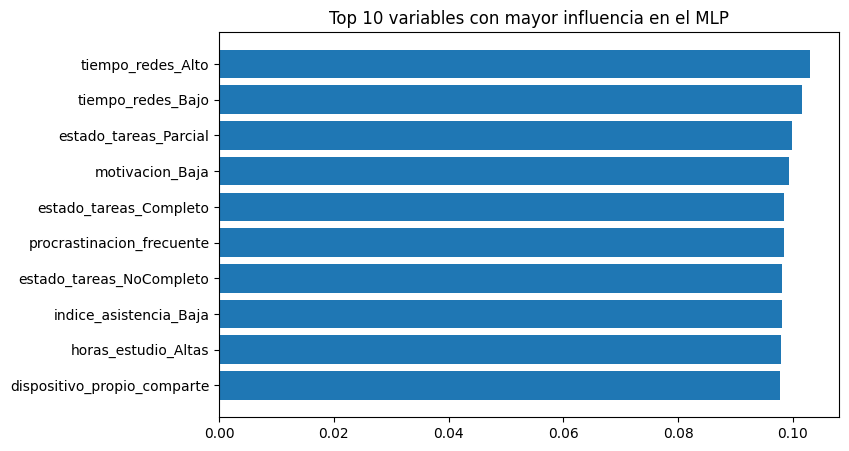

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Buscar la primera capa con pesos
for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        pesos = weights[0]
        break

# Calcular la importancia promedio absoluta por variable
importancia = np.mean(np.abs(pesos), axis=1)

# Crear DataFrame ordenado
imp_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancia
}).sort_values('Importancia', ascending=False)

# Mostrar las 10 más influyentes
print(imp_df.head(10))

# Visualización
plt.figure(figsize=(8,5))
plt.barh(imp_df['Variable'][:10], imp_df['Importancia'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 variables con mayor influencia en el MLP")
plt.show()

## 5) Curvas de entrenamiento (loss, accuracy, learning rate)

Grafica loss/accuracy (y LR) para ver aprendizaje y sobreajuste.

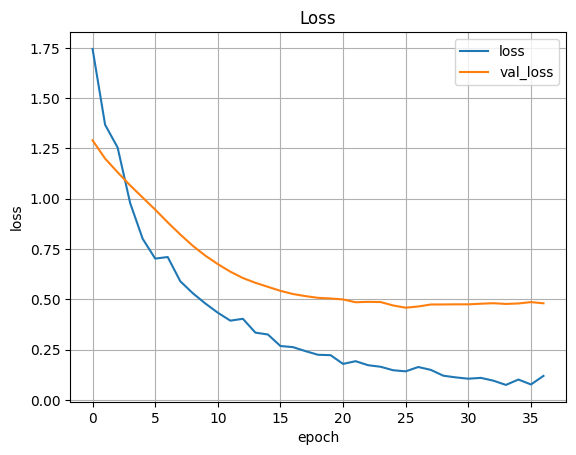

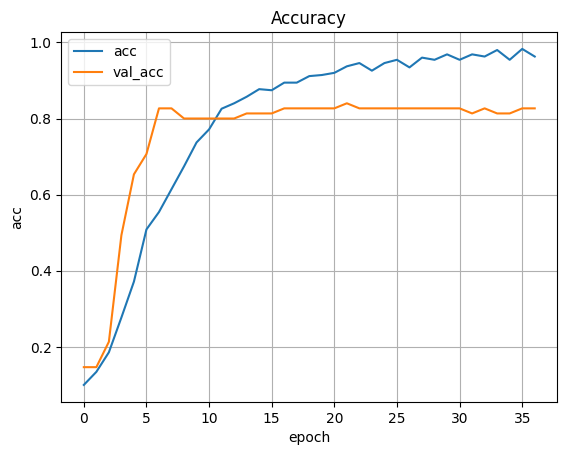

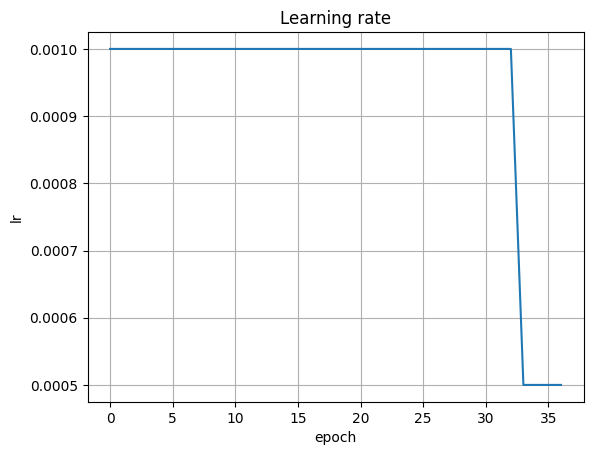

In [ ]:
plt.figure(); plt.plot(hist.history["loss"], label="loss"); plt.plot(hist.history["val_loss"], label="val_loss")
plt.legend(); plt.title("Loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True)

plt.figure(); plt.plot(hist.history["accuracy"], label="acc"); plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.legend(); plt.title("Accuracy"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.grid(True)

plt.figure(); plt.plot(hist.history.get("lr", [])); plt.title("Learning rate"); plt.xlabel("epoch"); plt.ylabel("lr"); plt.grid(True)


### 1) Pérdida (Loss)

- Train loss cae de ~1.8 a ~0.1 → el MLP sí aprende patrones.
- Val loss baja al inicio y se estabiliza en ~0.48–0.50 desde ~época 12.
- Lectura: la brecha grande (train ≪ val) indica sobreajuste: el modelo memoriza detalles de train que no generalizan.

### 2) Exactitud (Accuracy)

- Train acc sube hasta ~0.97–0.99.
- Val acc sube rápido y se queda en ~0.82 desde ~época 8–10.
- Lectura: confirma el estancamiento.
Nota: con clases desbalanceadas, 0.82 puede ocultar bajo recall en Bajo/Medio → evaluar también macro-F1 y matriz de confusión.

### 3) Tasa de aprendizaje (Learning rate)

- LR se mantiene en 1e-3 y recién cae a 5e-4 cerca de la época 33 (por ReduceLROnPlateau).
- Lectura: el ajuste del LR llega tarde; la validación ya estaba en meseta desde ~época 12.

## 6) Evaluación en test

Calcula accuracy, macro-F1, classification report y matriz de confusión

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
accuracy_test: 0.84
macro_f1_test: 0.529949381327334
              precision    recall  f1-score   support

        Bajo       0.50      0.20      0.29         5
       Medio       0.60      0.27      0.38        11
        Alto       0.87      1.00      0.93        59

    accuracy                           0.84        75
   macro avg       0.66      0.49      0.53        75
weighted avg       0.80      0.84      0.80        75



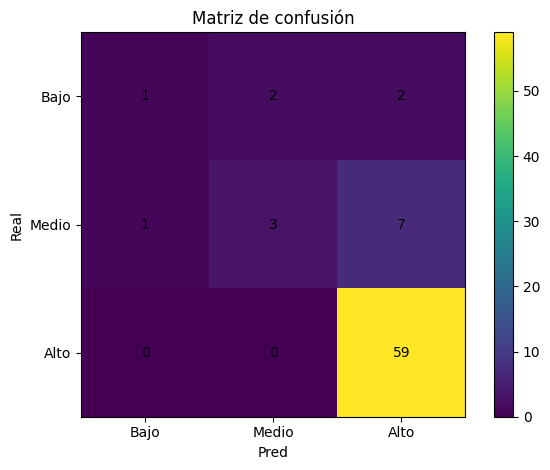

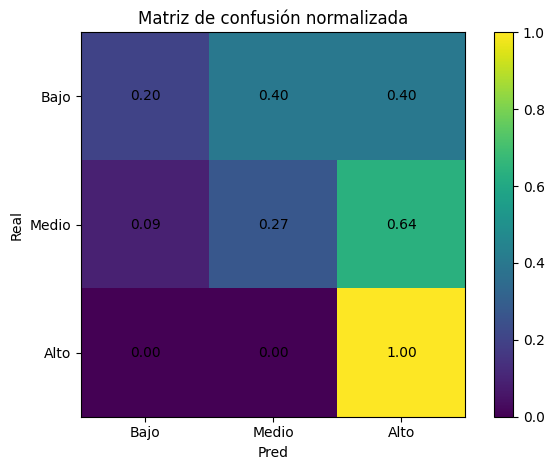

In [ ]:
probs = model.predict(X_test)
y_pred = probs.argmax(1)
print("accuracy_test:", accuracy_score(y_test, y_pred))
print("macro_f1_test:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, target_names=["Bajo","Medio","Alto"]))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Matriz de confusión")
plt.xticks([0,1,2], ["Bajo","Medio","Alto"]); plt.yticks([0,1,2], ["Bajo","Medio","Alto"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Pred"); plt.ylabel("Real"); plt.colorbar(); plt.tight_layout()

cmn = cm / cm.sum(axis=1, keepdims=True)
plt.figure()
plt.imshow(cmn, interpolation='nearest')
plt.title("Matriz de confusión normalizada")
plt.xticks([0,1,2], ["Bajo","Medio","Alto"]); plt.yticks([0,1,2], ["Bajo","Medio","Alto"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center")
plt.xlabel("Pred"); plt.ylabel("Real"); plt.colorbar(); plt.tight_layout()


## Matriz de confusión (test)

1.  El modelo acierta muy bien “Alto” pero le cuesta detectar “Bajo” y “Medio”.
2.  Resultado coherente con desbalance: la clase mayoritaria (“Alto”) domina la decisión.

## Números que contar (desde la matriz)
**Recall (sensibilidad) por clase — ¿cuántos de cada clase real recupera?**
- Bajo: 0.20 → solo 1 de 5 se detecta como “Bajo”; el 80% se confunde (40%→“Medio”, 40%→“Alto”).
- Medio: 0.27 → 3 de 11; 64% termina etiquetado como “Alto”.
- Alto: 1.00 → 59 de 59; prácticamente perfecto.

**Precision por clase — ¿qué tan “limpias” son las predicciones?**

- Bajo: 0.50 (1/2).
- Medio: 0.60 (3/5).
- Alto: 0.87 (59/68).

Global: Accuracy ≈ 0.84 (63/75).

Ojo: la accuracy luce alta por el peso de “Alto”. Macro-F1 ≈ 0.53 (promedio simple por clase) muestra mejor la brecha en Bajo/Medio.






## 7) ROC y Precision–Recall (one-vs-rest)

AUC y AP one-vs-rest por clase (Bajo/Medio/Alto) para medir calidad de ranking.

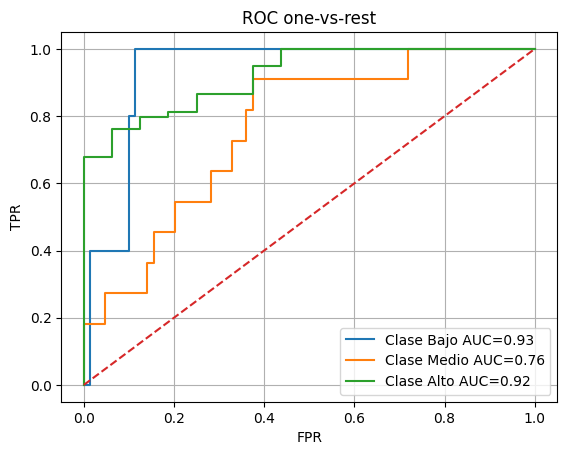

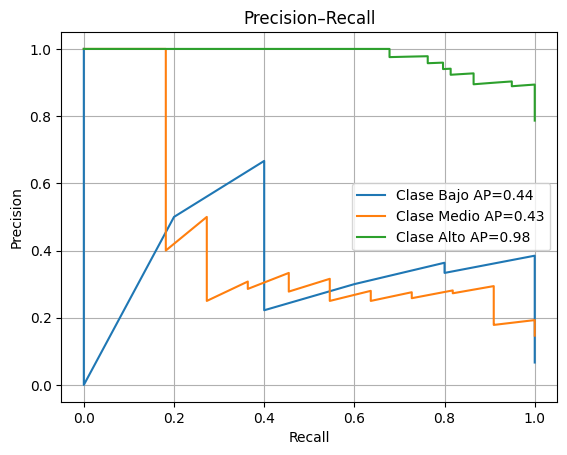

In [ ]:
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure()
for c in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:,c], probs[:,c])
    plt.plot(fpr, tpr, label=f"Clase {['Bajo','Medio','Alto'][c]} AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC one-vs-rest"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(True)

plt.figure()
for c in range(3):
    p, r, _ = precision_recall_curve(y_bin[:,c], probs[:,c])
    ap = average_precision_score(y_bin[:,c], probs[:,c])
    plt.plot(r, p, label=f"Clase {['Bajo','Medio','Alto'][c]} AP={ap:.2f}")
plt.title("Precision–Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(True)


## ROC y Precision–Recall (test)

- El modelo ordena muy bien “Alto” y “Bajo” (AUC altos), pero convertir ese ranking en aciertos útiles es más difícil en las clases minoritarias (AP moderado en Bajo/Medio).
- “Medio” es la clase más débil.

ROC one-**vs**-rest (capacidad de ranking)

- Bajo: AUC = 0.93 → separa bien Bajo del resto.
- Medio: AUC = 0.76 → separación limitada.
- Alto: AUC = 0.92 → separación muy buena.
- Interpretación: Independiente del umbral, el modelo asigna probabilidades más altas a la clase correcta—sobre todo en Alto y Bajo.

*Precision–Recall* (útil con desbalance)

- Bajo: AP = 0.44
- Medio: AP = 0.43
- Alto: AP = 0.98
- Interpretación: Para Bajo y Medio, al aumentar el recall (capturar más casos) la precisión cae rápido → hay mezcla con otras clases. En Alto casi todo lo que marca, acierta.

## 8) Diagrama de arquitectura (nodos por capa)

Gráfico “nodos por capa” del MLP (entrada, ocultas, salida)

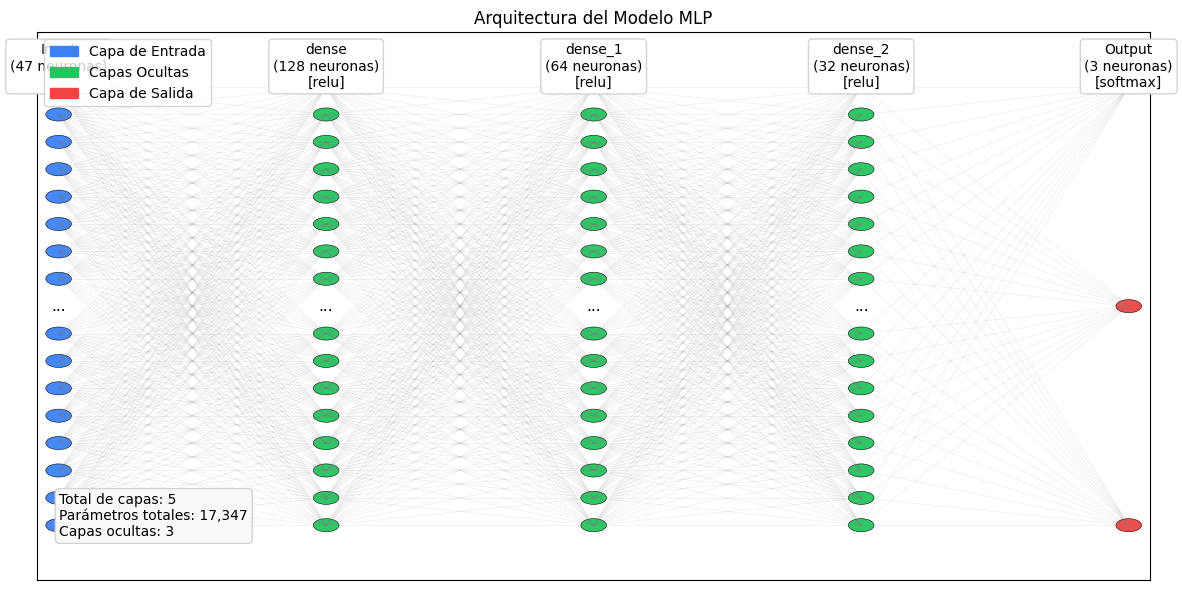

In [ ]:
from matplotlib.patches import Circle, Patch
import numpy as np

def plot_architecture(model, input_dim=None, max_nodes=16, line_alpha=0.12, lw=0.6,
                      title="Arquitectura del Modelo MLP",
                      color_in="#3b82f6", color_hid="#22c55e", color_out="#ef4444"):
    dense_layers = [l for l in model.layers if isinstance(l, layers.Dense)]
    if input_dim is None:
        input_dim = int(model.input_shape[1])
    units = [input_dim] + [int(l.units) for l in dense_layers]
    activs = ["input"] + [getattr(l.activation, "__name__", str(l.activation)) for l in dense_layers]
    names  = ["Input"] + [l.name for l in dense_layers]
    n_layers = len(units)
    xs_layers = np.linspace(0, 1, n_layers)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(title)

    def layer_positions(n, xval):
        if n <= max_nodes:
            ys = np.linspace(0.9, 0.1, n); dots=False
        else:
            top = max_nodes//2; bot = max_nodes - top
            ys = np.concatenate([np.linspace(0.9, 0.55, top),
                                 np.linspace(0.45, 0.1, bot)]); dots=True
        xs = np.full_like(ys, xval, dtype=float); return xs, ys, dots

    layers_pos = [layer_positions(n, x) for n, x in zip(units, xs_layers)]

    for i in range(n_layers-1):
        xL, yL, _ = layers_pos[i]; xR, yR, _ = layers_pos[i+1]
        li = np.linspace(0, len(yL)-1, min(len(yL), 18), dtype=int)
        rj = np.linspace(0, len(yR)-1, min(len(yR), 18), dtype=int)
        for a in li:
            for b in rj:
                plt.plot([xL[a], xR[b]], [yL[a], yR[b]], color="gray", alpha=line_alpha, linewidth=lw)

    for i, (xv, (xs, ys, dots)) in enumerate(zip(xs_layers, layers_pos)):
        n = units[i]; is_in=(i==0); is_out=(i==n_layers-1)
        col = color_in if is_in else (color_out if is_out else color_hid)
        for (xk, yk) in zip(xs, ys):
            plt.gca().add_patch(Circle((xk, yk), 0.012, facecolor=col, edgecolor="black", linewidth=0.4, alpha=0.95))
        if dots: plt.text(xs[0], 0.5, "...", ha="center", va="center", fontsize=11)
        title_cap = "Input" if is_in else ("Output" if is_out else names[i])
        act = "" if is_in else f"[{activs[i]}]"
        plt.text(xv, 0.98, f"{title_cap}\n({n} neuronas)\n{act}", ha="center", va="top",
                 bbox=dict(boxstyle="round", fc="white", ec="lightgray"))

    legend = [Patch(color=color_in,  label="Capa de Entrada"),
              Patch(color=color_hid, label="Capas Ocultas"),
              Patch(color=color_out, label="Capa de Salida")]
    plt.legend(handles=legend, loc="upper left", frameon=True)
    info = (f"Total de capas: {len(units)}\nParámetros totales: {model.count_params():,}\nCapas ocultas: {max(0, len(units)-2)}")
    plt.text(0.02, 0.08, info, transform=plt.gca().transAxes, fontsize=10, bbox=dict(boxstyle="round", fc="#f9f9f9", ec="lightgray"))
    plt.xticks([]); plt.yticks([]); plt.xlim(-0.02, 1.02); plt.ylim(0,1); plt.tight_layout(); plt.show()

plot_architecture(model, max_nodes=16, title="Arquitectura del Modelo MLP")


**Entrada (47):**
Cada círculo representa una feature one-hot (tareas, asistencia, sueño, redes, etc.).
Todas las entradas están totalmente conectadas con la primera capa oculta.

**Capas** ocultas (ReLU)

- Dense (128) → aprende combinaciones no lineales ricas de las variables.
- Dense (64) → comprime y depura representaciones útiles.
- Dense (32) → termina de extraer señales más compactas y robustas.

**Salida (3, Softmax)**
- Tres neuronas que entregan probabilidades para Bajo / Medio / Alto.
La clase final es la de mayor probabilidad (o se puede usar umbrales por clase).

**Capas totales: 5 | Ocultas: 3 | Parámetros: ~17,3K**
- Es un modelo rápido de entrenar e inferir, adecuado para despliegue en entornos modestos.

## 9) Predicción individual desde categorías (helper `vectorizar`)

Helper vectorizar({...}) convierte categorías a one-hot y predice un alumno.

In [ ]:
cols = list(X.columns)
def vectorizar(cat):
    row = pd.Series(0.0, index=cols, dtype="float32")
    for k,v in cat.items():
        col = f"{k}_{v}"
        if col in row.index:
            row[col] = 1.0
    return row.to_frame().T

ejemplo = vectorizar({
    "estado_tareas":"Completo",
    "indice_asistencia":"Alta",
    "horas_sueno":"Adecuado",
    "tiempo_redes":"Bajo"
})
print(["Bajo","Medio","Alto"][model.predict(ejemplo).argmax(1)[0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Alto


## 10) Guardar modelo y métricas

Exporta modelo_rna.keras y metricas_test.csv

In [ ]:
model.save("modelo_rna.keras")
pd.Series({
    "accuracy_test": accuracy_score(y_test, y_pred),
    "macro_f1_test": f1_score(y_test, y_pred, average="macro")
}).to_csv("metricas_test.csv")
print("Guardado: modelo_rna.keras, metricas_test.csv")


Guardado: modelo_rna.keras, metricas_test.csv
